Размер тренировочной выборки: (60000, 28, 28)
Размер тестовой выборки: (10000, 28, 28)


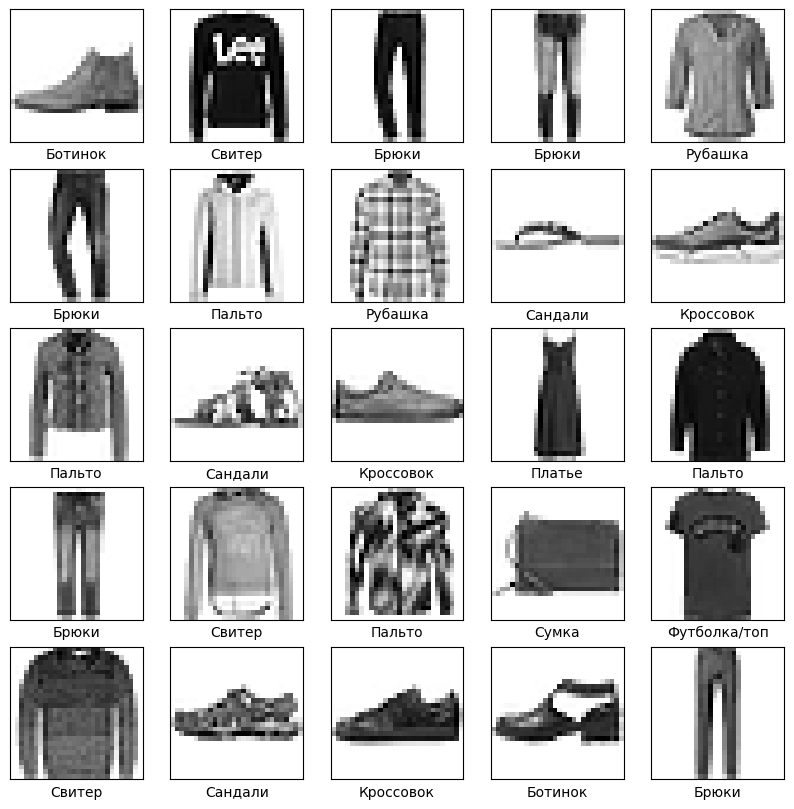

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8233 - loss: 0.4997 - val_accuracy: 0.8376 - val_loss: 0.4478
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8650 - loss: 0.3754 - val_accuracy: 0.8541 - val_loss: 0.4014
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8776 - loss: 0.3390 - val_accuracy: 0.8682 - val_loss: 0.3691
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8839 - loss: 0.3150 - val_accuracy: 0.8684 - val_loss: 0.3697
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8895 - loss: 0.2977 - val_accuracy: 0.8733 - val_loss: 0.3546
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8953 - loss: 0.2824 - val_accuracy: 0.8802 - val_loss: 0.3444
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8984 - loss: 0.2717 - val_accuracy: 0.8803 - val_loss: 0.3416
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9036 - loss: 0.2569 - val_accu

In [ ]:
from __future__ import absolute_import, division, print_function, unicode_literals

import tensorflow as tf
import tensorflow_datasets as tfds

import math
import numpy as np
import matplotlib.pyplot as plt

class_names = ['Футболка/топ', 'Брюки', 'Свитер', 'Платье', 'Пальто', 'Сандали', 'Рубашка', 'Кроссовок', 'Сумка', 'Ботинок']
# загружаем и распаковываем датасет
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data() # x_train - (60000, 28, 28)

print(f"Размер тренировочной выборки: {x_train.shape}")
print(f"Размер тестовой выборки: {x_test.shape}")

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

plt.figure(figsize=(10, 10))
i = 0
for index in range(25):
  image = x_test[index].reshape((28, 28))
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(image, cmap=plt.cm.binary)
  plt.xlabel(class_names[y_test[index]])
  i += 1
plt.show()

model = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28, 1)), # слой преобразования 2д объекта в 1д
  tf.keras.layers.Dense(128, activation=tf.nn.relu), # полносвязный слой 128 нейронов с функцией активацией (решает передавать значение нейрона на следующий слой или нет) - не пропускает оттрицательные значения
  tf.keras.layers.Dense(10, activation=tf.nn.softmax), # softmax - каждый нейрон получает значения всех предыдущих нейронов (128) и преобразовывает значения в корректный вид вероятности с общ суммой 1.0
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) # компилирование модели

# обучаем модель
model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test))



In [ ]:
# проведем проверка на тестовом наборе
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Точность на тестовом наборе данных: {test_accuracy} | Функция потерь: {test_loss}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8748 - loss: 0.3568
Точность на тестовом наборе данных: 0.8748000264167786 | Функция потерь: 0.3568063974380493


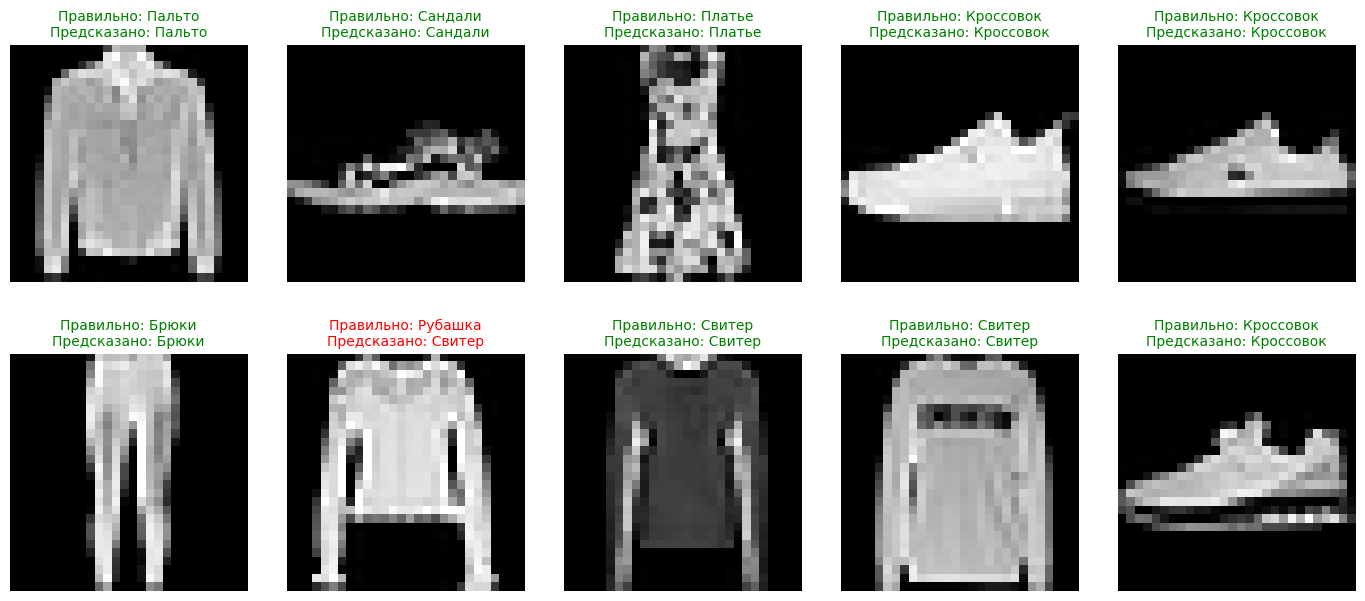

In [ ]:
number_of_images = 10
random_indexes = np.random.choice(len(x_test), size=number_of_images, replace=False)
predictions = model.predict(x_test[random_indexes], verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

# выведем результат предсказаний
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for i in range(number_of_images):
    ax = axes[i]

    # отрисовываем картинку
    ax.imshow(x_test[random_indexes[i]], cmap='gray')

    # берем правильную и предсказанную метки
    true_label = class_names[y_test[random_indexes[i]]]
    pred_label = class_names[predicted_labels[i]]

    # добавим цвет для наглядности
    color = 'green' if true_label == pred_label else 'red'

    ax.set_title(f'Правильно: {true_label}\nПредсказано: {pred_label}',
                 color=color, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.show()